In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def f(x):
    if 8 <= x <= 10: return x - 8
    elif 10 < x <= 12: return 12 - x
    else: return 0  

# Parameters
dt = 5e-12 
dx = 0.1
x_max = 20 # transmission line length
t_max = 2e-9 # final time
L = 4e-9
C = 1.6e-12
Z0 = np.sqrt(L / C) # characteristic impedance
vp = 1 / np.sqrt(L * C) # wave velocity

# Parâmetros de grade
nx = int(x_max / dx) + 1
nt = int(t_max / dt) + 1
C2 = (vp * dt / dx)**2 

# Inicialização da matriz de potencial V[tempo, espaço]
V = np.zeros((nt, nx))

# condição inicial
x = np.linspace(0, x_max, nx)
initial = np.zeros(nx)

for i in range (nx):
    initial[i] = f(x[i])

V[0, :] = initial

# Primeiro passo de tempo
for i in range(1, nx - 1):
    V[1, i] = V[0, i]

# Loop Principal
for n in range(1, nt - 1):
    V[n+1, 1:-1] = C2 * (V[n, 2:] - 2*V[n, 1:-1] + V[n, :-2]) + 2*V[n, 1:-1] - V[n-1, 1:-1]

    # condições de contorno
    V[n+1, 0] = V[n, 1] # em x = 0
    V[n+1, -1] = V[n, -2] # em x = 20


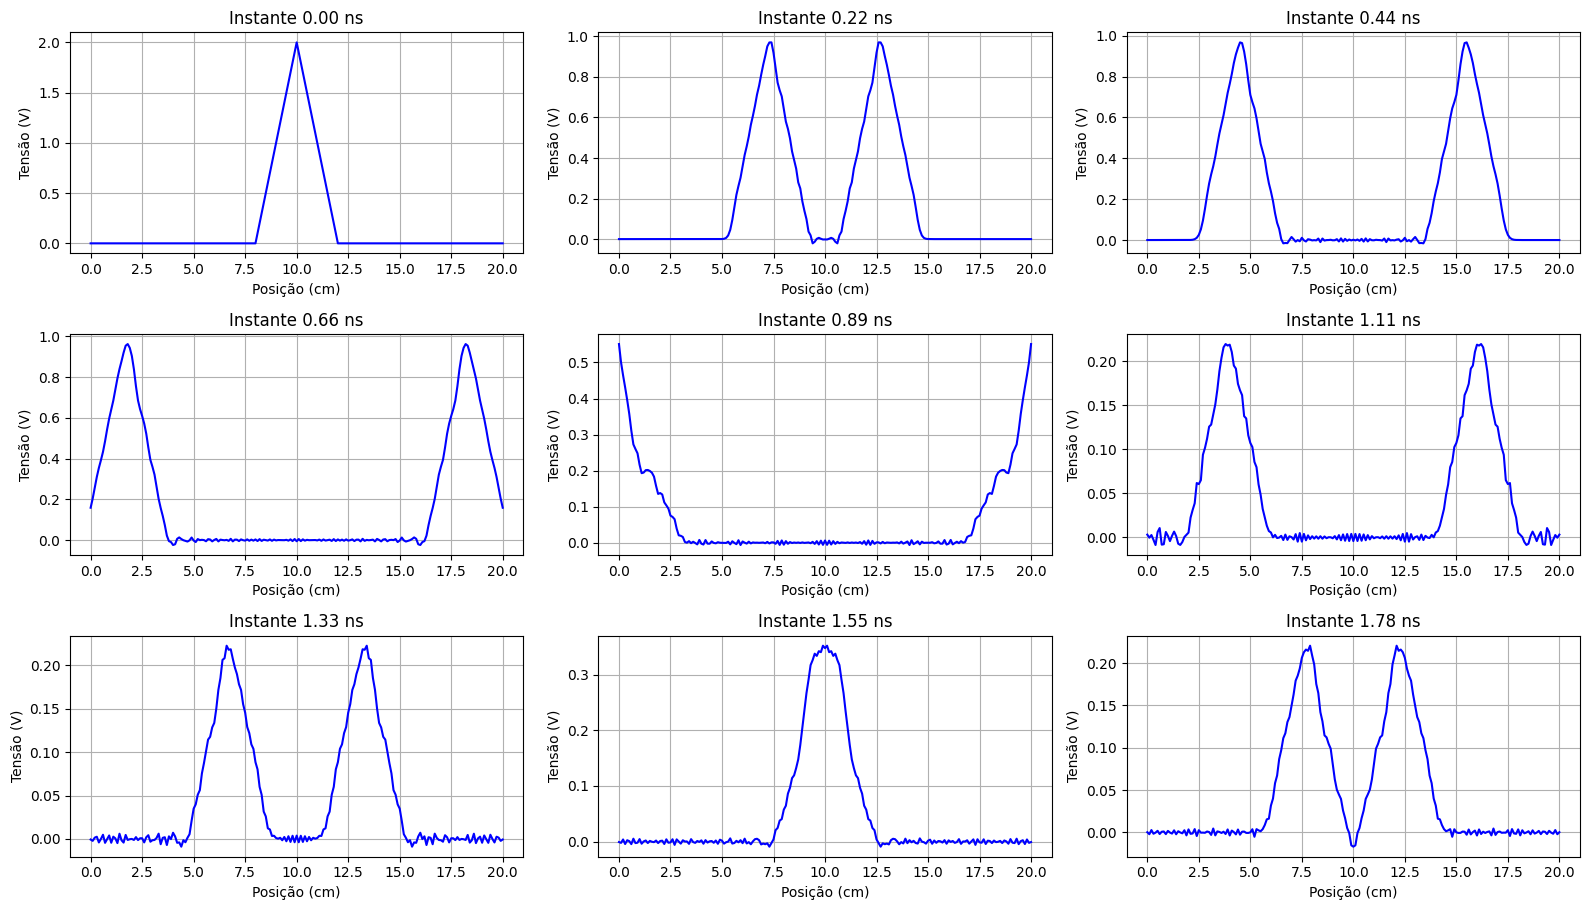

In [3]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))

t_list = []
for i in range(9):
    t_list.append(int(i * nt / 9))

for i, ax in enumerate(axes.flatten()):
    ax.plot(x, V[t_list[i], :], color='blue') # Plot the i-th dataset on the i-th axis
    ax.set_title(f'Instante {t_list[i] * dt * 1e9:.2f} ns')      # Set a title for each subplot
    ax.set_xlabel('Posição (cm)')
    ax.set_ylabel('Tensão (V)')
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

plt.show()